# XSEA: X-Set Enrichment Analysis (cf: ABAnnotate)

Gene-set or gene-category enrichment analysis (GSEA or GCSEA) usually refers to analysis frameworks that test if a set of genes that you are interested in (e.g., genes found in a disease-GWAS) are found more often in some given sets of genes (e.g., marker genes of specific neural cell types) than expected under assumption of randomness. This idea was adopted to the field of neuroimaging some time ago already. The method introduced here was significantly inspired by Ben Fulcher's [paper](https://doi.org/10.1038/s41467-021-22862-1) and [matlab code](https://github.com/benfulcher/GeneCategoryEnrichmentAnalysis). 

In 2023, I build a toolbox from Ben Fulcher's code, called [ABAnnotate](https://github.com/LeonDLotter/ABAnnotate). ABAnnotate will not be further developed, but it's functionality is now part of NiSpace.

## The Method

Neuroimaging GSEA most often works on a single input brain map defined by the user and thousands of Allen Human Brain Atlas gene expression maps. The core idea is rather simple: We define some gene sets of interest (e.g., cell type markers). We correlate our input map with all gene expression maps in each gene set. We take the average of these correlations per set as our association measure. We then randomly sample new gene sets from the whole dataset of genes, keeping the size of the gene sets constant, and calculate the average correlation again. These will form the null distribution to which our association measure can be compared.  
As you will see, NiSpace allows two ocre versions of this null test: Sample random gene sets from a larger dataset or don't sample random genes but create null maps of the *input* brain map.

### "XSEA"?

In NiSpace, we do not use the term GSEA, but generalize it to XSEA, which stands for X-Set Enrichment Analysis. We use "X" in the linear-model-sense as "predictor". There was no reason to limit NiSpace's set-enrichment analysis functionality to gene expression data. Instead, the XSEA methods work on any kind of input data that is organized into sets of maps. For example, we can also analyze PET maps (e.g., a serotonin set could consist of 5HT1a, 5HT2a, 5HT4, and 5HT6 maps) or neurosynth meta-analysis term maps that way (e.g., a "sensory" set could consist of maps for "visual", "auditory", and "somatosensory" terms).

## NiSpace vs. ABAnnotate

NiSpace is a much more recent project and has been developed with the goal of flexibility, while still providing a user-friendly interface.  
Especially, the map-based null models are much more advanced than in ABAnnotate, leading to different results. Developments include:

- Flexible null model combinations
- Moran randomization as the default map-based null model
- Enforcing level of bilateral symmetry of the null maps to match the input map
- Extending the set-enrichment method to all types of included reference data
- Allen Brain Atlas mRNA data is for now provided only for genes that showed an average across-donor Spearman's rho of at least 0.1
- Many different parcellations
- Works with MNI, fsaverage, and fsLR input data
- Last but not least: Python as an open-source language with a large community and the likely future of neuroimaging analysis (yes, I know, I'm biased)

The following example is provided as comparison to the [example](https://github.com/LeonDLotter/ABAnnotate/blob/main/example/example_pain.md) in the ABAnnotate repository.

## Imports

In [1]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

# general imports
import matplotlib.pyplot as plt
import pandas as pd

# import imaging functions
from nilearn.image import load_img
from nilearn.plotting import view_img

## Get an input brain map

This is a meta-analytically derived map automatically generated from the "pain" neuroscientific literature via [NeuroQuery](https://neuroquery.org/query?text=pain+).

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



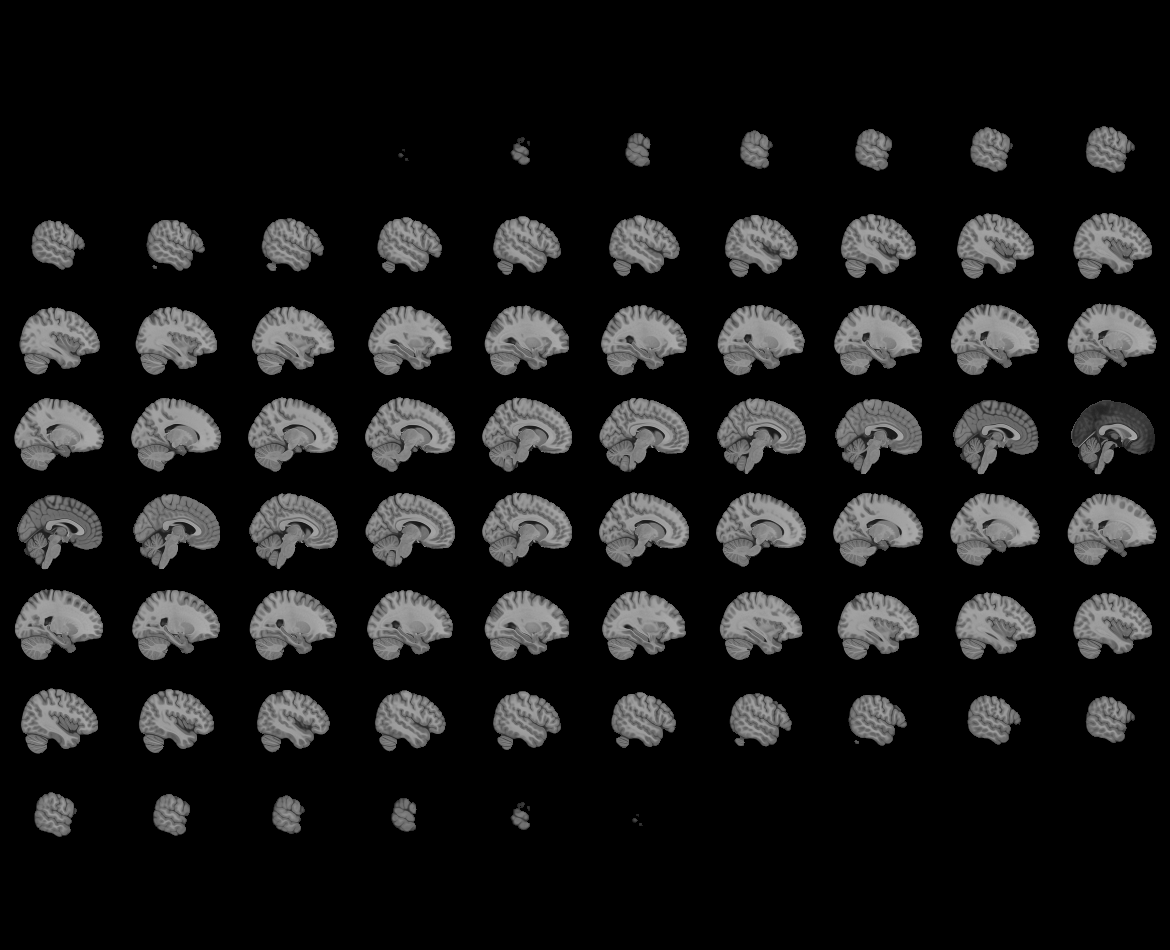
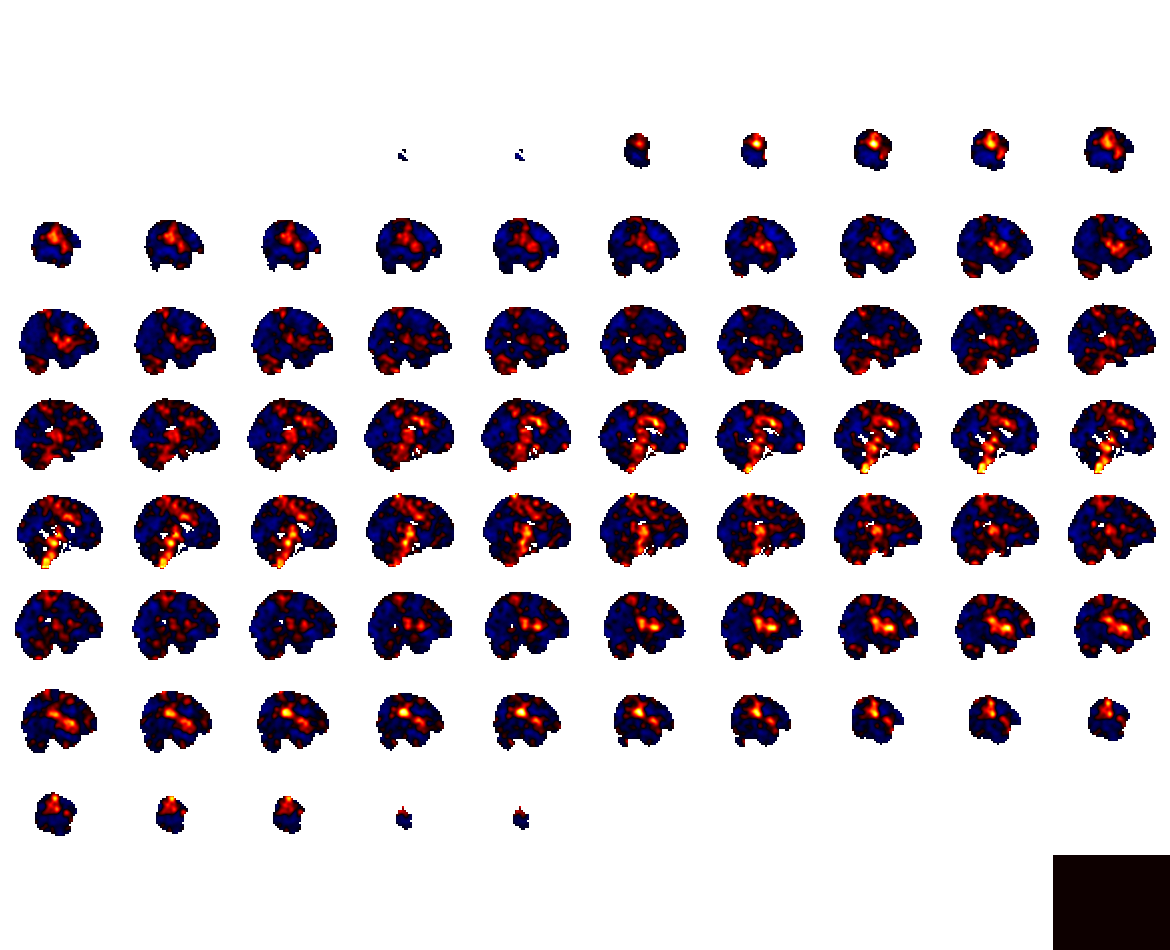

In [2]:
# the download function is a simple function to download a file from a url and save it to a temporary directory
file_path = "neuroquery/pain.nii.gz"

# load the map into memory
effect_map = load_img(file_path)

# plot the map interactively
view_img(effect_map)

## Neuronal cell type marker gene sets

NiSpace comes with some collections of gene sets, which are to be extended in the future.  
It's easy to add your own gene sets, but you can always ask to add a collection via a [GitHub issue](https://github.com/LeonDLotter/NiSpace/issues).

For comparison with the ABAnnotate example, we will use a cell type collection: "CellTypesPsychEncodeTPM".

In NiSpace, we call any grouping of predictor X maps a "collection". Collections can just be a list of maps to subset a larger dataset, or multiple sets of maps. Each map can additionally be associated with a weight.  
Collections are stored in the NiSpace data repository as text files. They can be loaded via the `fetch_collection` function, or directly with the actual region-wise data via the `fetch_reference` function.

Here, we take a look at the collection "CellTypesPsychEncodeTPM" from the "mrna" dataset.

If you want to provide your own collection, create a pandas table like the one below and pass it directly to the `collection` parameter.

In [3]:
from nispace.datasets import fetch_collection

fetch_collection("CellTypesPsychEncodeTPM", dataset="mrna")

INFO | 08/09/25 08:34:30 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.
INFO | 08/09/25 08:34:30 | nispace: Filtering maps by collection.


,set,map
0,Ex1 CortProject (L2/3),CAMK2A
1,Ex1 CortProject (L2/3),CCDC88C
2,Ex1 CortProject (L2/3),CDH9
3,Ex1 CortProject (L2/3),DNM1
4,Ex1 CortProject (L2/3),GNAL
...,...,...
587,Oligodendrocyte,RNASE1
588,Oligodendrocyte,RRBP1
589,Oligodendrocyte,TF
590,Oligodendrocyte,TMEM144


With mRNA data from the Allen Human Brain Atlas (cortex parcellation: Schaefer100 + Subcortex parcellation: TianS1), this looks like:

NOTE: I realized that the FreeSurfer parcellations (DesikanKilliany, DesikanKillianyTourville, and Destriex) can have quite different output profiles in comparison to the Schaefer parcellations. 
Esp. when comparing "input map" vs "gene set" null models as shown below.  
It will be worth comparing the results of different parcellations, if possible for your pipeline.

In [4]:
from nispace.datasets import fetch_reference

# parcellation to use throughout the analysis
parcellation = "Schaefer100TianS1"

# showcase data
fetch_reference("mrna", parcellation=parcellation, collection="CellTypesPsychEncodeTPM")

INFO | 08/09/25 08:34:30 | nispace: Loading mrna maps.
INFO | 08/09/25 08:34:30 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.
INFO | 08/09/25 08:34:30 | nispace: Filtering maps by collection.
INFO | 08/09/25 08:34:30 | nispace: Loading and inner-merging data parcellated with 'Schaefer100' and 'TianS1'
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six donors, mapped onto MNI or fsaverage parcels using the abagen toolbox (Markello et al., 2021, https://doi.org/10.7554/eLife.72129).
The data was extracted using abagen.get_expression_data(..., lr_mirror="bidirectional"), considering parcel hemisphere and 
cortical vs. subcortical location. Only genes that showed a mean donor-to-donor Spearman correlation of > 0.1 were retained.
In addition to the two pub

hemi-L_div-Vis_lab-1  hemi-L_div-Vis_lab-2  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.842136              0.826765   
                       CDH9                 0.742186              0.618615   
                       GNAL                 0.574698              0.445492   
                       GPR83                0.481428              0.385518   
                       GREB1L               0.524661              0.492791   
...                                              ...                   ...   
Oligodendrocyte        PLP1                 0.496111              0.617112   
                       RNASE1               0.482726              0.583546   
                       TF                   0.493476              0.601608   
                       TMEM144              0.464793              0.543832   
                       UGT8                 0.468218              0.563882   

                                hemi-L_div-Vis_lab-3  hemi-L_div-Vis_lab-4  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.826967              0.827184   
                       CDH9                 0.623595              0.567650   
                       GNAL                 0.482613              0.427197   
                       GPR83                0.402124              0.335082   
                       GREB1L               0.433349              0.499530   
...                                              ...                   ...   
Oligodendrocyte        PLP1                 0.527995              0.528311   
                       RNASE1               0.498163              0.462077   
                       TF                   0.550798              0.475832   
                       TMEM144              0.462347              0.473897   
                       UGT8                 0.481012              0.483897   

                                hemi-L_div-Vis_lab-5  hemi-L_div-Vis_lab-6  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.817241              0.822723   
                       CDH9                 0.546706              0.577347   
                       GNAL                 0.396329              0.454356   
                       GPR83                0.332499              0.363270   
                       GREB1L               0.460485              0.468639   
...                                              ...                   ...   
Oligodendrocyte        PLP1                 0.550389              0.591656   
                       RNASE1               0.527777              0.544846   
                       TF                   0.503930              0.596859   
                       TMEM144              0.494475              0.548147   
                       UGT8                 0.527683              0.571186   

                                hemi-L_div-Vis_lab-7  hemi-L_div-Vis_lab-8  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.815382              0.818394   
                       CDH9                 0.681953              0.648653   
                       GNAL                 0.421469              0.467101   
                       GPR83                0.409938              0.360245   
                       GREB1L               0.413786              0.436790   
...                                              ...                   ...   
Oligodendrocyte        PLP1                 0.531964              0.492399   
                       RNASE1               0.529359              0.471896   
                       TF                   0.524158              0.464836   
                       TMEM144              0.490285              0.461037   
                       UGT8                 0.51048

## Run the analysis 

We will now run the analysis using a `workflow` function from NiSpace. Workflow functions run a complete analysis, from data loading to plotting, with a single function call.    
We can pass the collection name directly (so, the two cell blocks above are not needed).

In [5]:
# set some parameters
# put into a dictionary to pass to the following functions
kwargs = {
    "parcellation": parcellation, # the parcellation to use, defined above
    "x_collection": "CellTypesPsychEncodeTPM", # the collection to use, here, CellTypesPsychEncodeTPM
    "seed": 42, # the seed to use for the permutation analysis, for reproducibility
    "n_proc": 4, # number of parallel processes to use when possible
    "plot": False, # dont plot, we will compare below
}

### Random sampling of gene sets

First, let's run a "classical" set enrichment analysis with random sampling of gene sets from the whole genome dataset 

In [6]:
from nispace.workflows import simple_xsea

colocalization_randomgenes, p_values_randomgenes, p_fdr_values_randomgenes, nispace_object_randomgenes = simple_xsea(
    y={"Pain": effect_map}, # our effect map, with the dictionary we can pass a name, can also be just the effect map
    x="mrna", # Allen Human Brain Atlas mRNA data extracted with the abagen package
    permute_sets=True, # permuting sets is not the default as you will see below, so we set it to True here
    **kwargs,
)

INFO | 08/09/25 08:34:31 | nispace: Trying to fetch background X dataset.
INFO | 08/09/25 08:34:31 | nispace: Loading mrna maps.
INFO | 08/09/25 08:34:31 | nispace: Loading and inner-merging data parcellated with 'Schaefer100' and 'TianS1'
INFO | 08/09/25 08:34:31 | nispace: Using integrated parcellation Schaefer100TianS1.
INFO | 08/09/25 08:34:31 | nispace: Loading integrated mrna dataset as X data.
INFO | 08/09/25 08:34:31 | nispace: Loading mrna maps.
INFO | 08/09/25 08:34:31 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.
INFO | 08/09/25 08:34:31 | nispace: Filtering maps by collection.
INFO | 08/09/25 08:34:31 | nispace: Loading and inner-merging data parcellated with 'Schaefer100' and 'TianS1'
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six don

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:34:35 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 08/09/25 08:34:35 | nispace: Got 'y' data for 1 x 116 parcels.
INFO | 08/09/25 08:34:35 | nispace: Z-standardizing 'X' data.
INFO | 08/09/25 08:34:35 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 08/09/25 08:34:35 | nispace: Running 'spearman' colocalization.
INFO | 08/09/25 08:34:35 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 08/09/25 08:34:35 | nispace: Using 24 sets with between 2 and 59 samples. Aggregating within-set colocalizations with: mean.
INFO | 08/09/25 08:34:35 | nispace: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:34:38 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 08/09/25 08:34:38 | nispace: Permutation of: X sets.
INFO | 08/09/25 08:34:38 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 08/09/25 08:34:38 | nispace: Generating permuted X sets.
INFO | 08/09/25 08:34:38 | nispace: Will use 9562 provided background maps.
INFO | 08/09/25 08:34:38 | nispace: Z-standardizing X background maps.


Permuting X set indices:   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 08/09/25 08:34:39 | nispace: Pre-ranking X and Y (null) data.


Null colocalizations (spearman, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 08/09/25 08:34:47 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 08/09/25 08:34:47 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 08/09/25 08:34:47 | nispace: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
INFO | 08/09/25 08:34:47 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | sets         | True | None      | False | False       | False       | 
INFO | 08/09/25 08:34:47 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | sets         | True | fdrbh     | False | False       | False       | 


### Permutation of the input map

Now, let's run a set-enrichment analysis, but do not randomize the gene sets and rather "permute" the input map (not actually permutation but sampling of null maps with similar spatial structure). This is the default setting in NiSpace adopted from ABAnnotate and Fulcher's paper.


In [7]:
colocalization_randominput, p_values_randominput, p_fdr_values_randominput, nispace_object_randominput = simple_xsea(
    y={"Pain": effect_map}, # our effect map, with the dictionary we can pass a name, can also be just the effect map
    x="mrna", # Allen Human Brain Atlas mRNA data extracted with the abagen package
    **kwargs
)

INFO | 08/09/25 08:34:47 | nispace: Using integrated parcellation Schaefer100TianS1.
INFO | 08/09/25 08:34:47 | nispace: Loading integrated mrna dataset as X data.
INFO | 08/09/25 08:34:47 | nispace: Loading mrna maps.
INFO | 08/09/25 08:34:47 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.
INFO | 08/09/25 08:34:47 | nispace: Filtering maps by collection.
INFO | 08/09/25 08:34:47 | nispace: Loading and inner-merging data parcellated with 'Schaefer100' and 'TianS1'
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six donors, mapped onto MNI or fsaverage parcels using the abagen toolbox (Markello et al., 2021, https://doi.org/10.7554/eLife.72129).
The data was extracted using abagen.get_expression_data(..., lr_mirror="bidirectional"), considering parcel hem

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:34:48 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 08/09/25 08:34:48 | nispace: Got 'y' data for 1 x 116 parcels.
INFO | 08/09/25 08:34:48 | nispace: Z-standardizing 'X' data.
INFO | 08/09/25 08:34:48 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 08/09/25 08:34:48 | nispace: Running 'spearman' colocalization.
INFO | 08/09/25 08:34:48 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 08/09/25 08:34:48 | nispace: Using 24 sets with between 2 and 59 samples. Aggregating within-set colocalizations with: mean.
INFO | 08/09/25 08:34:48 | nispace: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:34:48 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 08/09/25 08:34:48 | nispace: Permutation of: Y maps.
INFO | 08/09/25 08:34:48 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 08/09/25 08:34:48 | nispace: Generating permuted Y maps.
INFO | 08/09/25 08:34:48 | nispace: Downsampling volumetric parcellation to voxelsize of 2 for distance matrix generation.
INFO | 08/09/25 08:34:49 | nispace: Estimating euclidean distance matrix between 116 volumetric parcels.


Running (4 proc):   0%|          | 0/116 [00:00<?, ?it/s]

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


INFO | 08/09/25 08:34:59 | nispace: No null maps found.
INFO | 08/09/25 08:34:59 | nispace: Generating null maps (n = 10000, null_method = 'moran').
INFO | 08/09/25 08:34:59 | nispace: Null map generation: Assuming n = 1 data vector(s) for n = 116 parcels.
INFO | 08/09/25 08:34:59 | nispace: Using provided distance matrix/matrices.
INFO | 08/09/25 08:34:59 | nispace: Generating null data separately for left and right hemisphere.


Moran null maps (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:02 | nispace: Left-to-right mirroring null maps (using left-to-right mapping).
INFO | 08/09/25 08:35:02 | nispace: Matching interhemispheric correlation. Observed correlation: 0.86


Mirroring null maps:   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:06 | nispace: Null data generation finished.
INFO | 08/09/25 08:35:06 | nispace: Running X Set Enrichment Analysis (XSEA) without set permutation.
INFO | 08/09/25 08:35:06 | nispace: Pre-ranking X and Y (null) data.


Processing null arrays (4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:16 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 08/09/25 08:35:16 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 08/09/25 08:35:16 | nispace: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
INFO | 08/09/25 08:35:16 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False | False       | False       | 
INFO | 08/09/25 08:35:16 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | fdrbh     | False | False       | False       | 


### Inspect the results

The workflow function returns dataframes with colocalization values, p values, and FDR-corrected p values. Let's take a look at the p values.

In [8]:
# Concatenate p values from both methods
p_values = pd.DataFrame(
    {
        "randomgenes": p_values_randomgenes.loc["Pain"],
        "randominput": p_values_randominput.loc["Pain"],
    }
)

# Display, sorted by the input map permutation results
p_values.sort_values(by="randominput")

,randomgenes,randominput
Ex8 Corticothalamic (L6),0.0014,0.0086
Developing-replicating,0.0456,0.0186
OPC,0.0001,0.0402
Ex7 Corticothalamic,0.1162,0.0646
Microglia,0.0001,0.0682
Ex6 SubcortProject (L5-6),0.0006,0.0856
Oligodendrocyte,0.0032,0.1120
Endothelial,0.0001,0.1794
Astrocyte,0.0004,0.2630
Ex3 Granule (L4),0.0086,0.2846


What does this tell us? On first glance, we can see that both methods suggested "Adult-Ex8" as (one of the) the strongest associated cell type relative to null models.  
This matches the result from the ABAnnotate example and adds some face validity as Ex8 was defined as corticothalamic projection neurons in the [publication](https://doi.org/10.1126/science.aaf1204) associated with the cell type collection.

However, we can also see two more things:
1. For the random gene set sampling, much more maps turn out to be significant than for the input null map method. This might indeed be an indication of inflated false positives! The initially cited paper by [Fulcher et al., 2021](https://doi.org/10.1038/s41467-021-22862-1) suggested this method to be affected by within-set coexpression patterns. The input null map method cannot have this problem, as the gene sets remain unchanged during the null runs.
2. The results seem somewhat more conservative than in the [ABAnnotate example](https://github.com/LeonDLotter/ABAnnotate/blob/main/example/example_pain.md). As listed above, there are many implementation differences, and I would generally suggest to trust the much more advanced NiSpace implementation.

### Plot side by side

We have an integrated plotting method for the NiSpace objects that were returned by the workflow functions.

INFO | 08/09/25 08:35:16 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 08/09/25 08:35:17 | nispace: Creating categorical plot for method spearman, colocalization stat rho.
INFO | 08/09/25 08:35:17 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 08/09/25 08:35:18 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


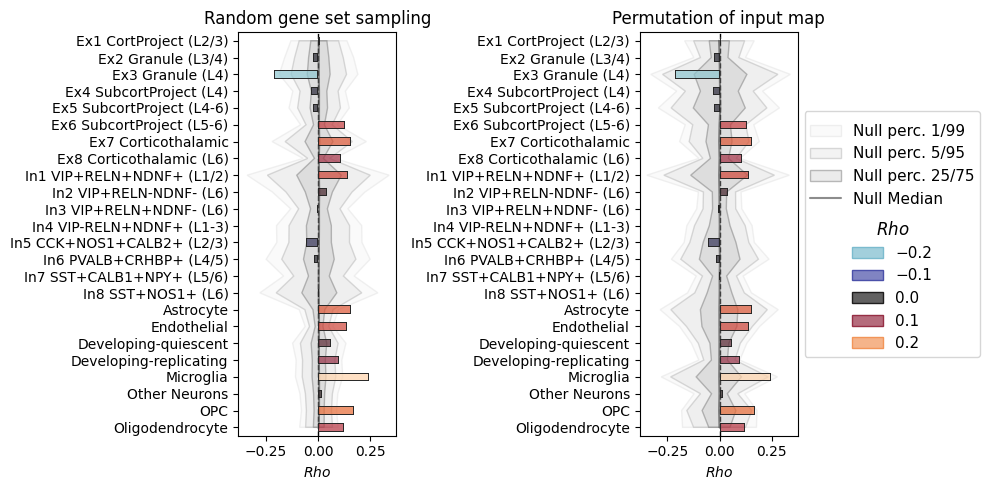

In [9]:
# create figure to host both plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True, sharex=True)

# plot both plots
nispace_object_randomgenes.plot(ax=axes[0], show=False, title="Random gene set sampling", fig=fig)
nispace_object_randominput.plot(ax=axes[1], show=False, title="Permutation of input map", fig=fig)

# hide legend of first plot
axes[0].legend_.set_visible(False)

# adjust layout
fig.tight_layout()

## Extra: Colocalization methods

An advantage of NiSpace is that it allows to flexibly use different colocalization methods. Above, we used Spearman's rho, but there are other options well suited for XSEA analysis.  
Good options are regression-based methods that reduce any number of predictors to one or more latent variables from which the dependent variable is then predicted.

We have partial least squares (`"pls"`) and principal component regression (`"pcr"`) as options.

Let's take a look at the results using PLS (default setting: n = 1 component).

In [10]:
colocalization_randomgenes_pls, p_values_randomgenes_pls, p_fdr_values_randomgenes_pls, _ = simple_xsea(
    y={"Pain": effect_map},
    x="mrna",
    colocalization_method="pls",
    permute_sets=True,
    **kwargs
)

INFO | 08/09/25 08:35:18 | nispace: Trying to fetch background X dataset.
INFO | 08/09/25 08:35:18 | nispace: Loading mrna maps.
INFO | 08/09/25 08:35:18 | nispace: Loading and inner-merging data parcellated with 'Schaefer100' and 'TianS1'
INFO | 08/09/25 08:35:19 | nispace: Using integrated parcellation Schaefer100TianS1.
INFO | 08/09/25 08:35:19 | nispace: Loading integrated mrna dataset as X data.
INFO | 08/09/25 08:35:19 | nispace: Loading mrna maps.
INFO | 08/09/25 08:35:19 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.
INFO | 08/09/25 08:35:19 | nispace: Filtering maps by collection.
INFO | 08/09/25 08:35:19 | nispace: Loading and inner-merging data parcellated with 'Schaefer100' and 'TianS1'
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six don

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:20 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 08/09/25 08:35:20 | nispace: Got 'y' data for 1 x 116 parcels.
INFO | 08/09/25 08:35:20 | nispace: Z-standardizing 'X' data.
INFO | 08/09/25 08:35:20 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 08/09/25 08:35:20 | nispace: Running 'pls' colocalization.
INFO | 08/09/25 08:35:20 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 08/09/25 08:35:20 | nispace: Using 24 sets with between 2 and 59 samples. Aggregating within-set colocalizations with: mean.


Colocalizing (pls, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:20 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 08/09/25 08:35:20 | nispace: Permutation of: X sets.
INFO | 08/09/25 08:35:20 | nispace: Loading observed colocalizations (method = 'pls').
INFO | 08/09/25 08:35:20 | nispace: Generating permuted X sets.
INFO | 08/09/25 08:35:20 | nispace: Will use 9562 provided background maps.
INFO | 08/09/25 08:35:20 | nispace: Z-standardizing X background maps.


Permuting X set indices:   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (pls, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

/Applications/miniforge3/envs/nsp309/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


INFO | 08/09/25 08:35:29 | nispace: Calculating exact p-values (tails = {'r2': 'upper', 'beta': 'two'}).
INFO | 08/09/25 08:35:30 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 08/09/25 08:35:30 | nispace: Returning colocalizations: 
| METHOD | XSEA | X_REDUCTION | Y_TRANSFORM | 
| pls    | True | False       | False       | 
INFO | 08/09/25 08:35:30 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | None      | False | False       | False       | 
INFO | 08/09/25 08:35:30 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | fdrbh     | False | False       | False       | 


Looking at the p values, we can see that the results are more conservative as compared to the Spearman's rho results, even though we used the gene permutation null model! This requires further testing, but could be due to completely different consideration of within-set correlations.  
Regression-based methods return stats as dictionaries, here with a "beta" and "r2" key.

In [11]:
p_values_randomgenes_pls["beta"].loc["Pain"].sort_values()

Endothelial                   0.0001
Ex8 Corticothalamic (L6)      0.0034
Microglia                     0.0110
OPC                           0.0156
Oligodendrocyte               0.0202
Ex6 SubcortProject (L5-6)     0.1014
Astrocyte                     0.1274
Ex4 SubcortProject (L4)       0.1374
Ex7 Corticothalamic           0.1740
In3 VIP+RELN+NDNF- (L6)       0.1796
Ex1 CortProject (L2/3)        0.2602
Ex3 Granule (L4)              0.2690
Ex5 SubcortProject (L4-6)     0.2790
Developing-replicating        0.4708
In6 PVALB+CRHBP+ (L4/5)       0.6770
In4 VIP-RELN+NDNF+ (L1-3)     0.6938
Other Neurons                 0.7052
In7 SST+CALB1+NPY+ (L5/6)     0.7660
In1 VIP+RELN+NDNF+ (L1/2)     0.8462
Ex2 Granule (L3/4)            0.8580
In2 VIP+RELN-NDNF- (L6)       0.9572
Developing-quiescent          0.9782
In5 CCK+NOS1+CALB2+ (L2/3)    0.9838
In8 SST+NOS1+ (L6)            0.9978
Name: Pain, dtype: float32

## Extra: Other mRNA expression dataset

Here's the same analysis but using Allen Brain Atlas based gene expression data reconstructed by [Wagstyl et al., 2024](https://doi.org/10.7554/eLife.86933.3).  
We get different numbers of genes with this dataset for the same parcellation because across-ABA-donor reproducibility was quantified in a different fashion.

The data is reconstructed on the cortex, so we will use the Schaefer100 parcellation.

In [12]:
colocalization_randomgenes_plsmagicc, p_values_randomgenes_plsmagicc, p_fdr_values_randomgenes_plsmagicc, _ = simple_xsea(
    y={"Pain": effect_map},
    x="magicc",
    colocalization_method="pls",
    permute_sets=True,
    **kwargs | {"parcellation": "Schaefer100"}
)

INFO | 08/09/25 08:35:30 | nispace: Trying to fetch background X dataset.
INFO | 08/09/25 08:35:30 | nispace: Loading magicc maps.
INFO | 08/09/25 08:35:30 | nispace: Loading data parcellated with 'Schaefer100'
INFO | 08/09/25 08:35:30 | nispace: Using integrated parcellation Schaefer100.
INFO | 08/09/25 08:35:30 | nispace: Loading integrated magicc dataset as X data.
INFO | 08/09/25 08:35:30 | nispace: Loading magicc maps.
INFO | 08/09/25 08:35:30 | nispace: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'magicc'.
INFO | 08/09/25 08:35:30 | nispace: Filtering maps by collection.
INFO | 08/09/25 08:35:30 | nispace: Loading data parcellated with 'Schaefer100'
The NiSpace "magicc" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six donors, mapped onto continuous fsLR space as described in Wag

Parcellating (4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:31 | nispace: Combined across images, 0 parcel(s) had only background intensity and were set to nan ([]).
INFO | 08/09/25 08:35:31 | nispace: Got 'y' data for 1 x 100 parcels.
INFO | 08/09/25 08:35:31 | nispace: Z-standardizing 'X' data.
INFO | 08/09/25 08:35:31 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 08/09/25 08:35:31 | nispace: Running 'pls' colocalization.
INFO | 08/09/25 08:35:31 | nispace: Will perform X-set enrichment analysis (XSEA).
INFO | 08/09/25 08:35:31 | nispace: Using 24 sets with between 2 and 51 samples. Aggregating within-set colocalizations with: mean.


Colocalizing (pls, 4 proc):   0%|          | 0/1 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:31 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 08/09/25 08:35:31 | nispace: Permutation of: X sets.
INFO | 08/09/25 08:35:31 | nispace: Loading observed colocalizations (method = 'pls').
INFO | 08/09/25 08:35:31 | nispace: Generating permuted X sets.
INFO | 08/09/25 08:35:31 | nispace: Will use 11146 provided background maps.
INFO | 08/09/25 08:35:31 | nispace: Z-standardizing X background maps.


Permuting X set indices:   0%|          | 0/10000 [00:00<?, ?it/s]

Null colocalizations (pls, 4 proc):   0%|          | 0/10000 [00:00<?, ?it/s]

INFO | 08/09/25 08:35:40 | nispace: Calculating exact p-values (tails = {'r2': 'upper', 'beta': 'two'}).
INFO | 08/09/25 08:35:40 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 08/09/25 08:35:40 | nispace: Returning colocalizations: 
| METHOD | XSEA | X_REDUCTION | Y_TRANSFORM | 
| pls    | True | False       | False       | 
INFO | 08/09/25 08:35:40 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | None      | False | False       | False       | 
INFO | 08/09/25 08:35:40 | nispace: Returning p values: 
| METHOD | PERMUTE_WHAT | XSEA | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM | 
| pls    | sets         | True | fdrbh     | False | False       | False       | 


Similar results reassure us of the robustness of our findings.

In [13]:
p_values_randomgenes_plsmagicc["beta"].loc["Pain"].sort_values()

Ex8 Corticothalamic (L6)      0.0002
Endothelial                   0.0042
Developing-replicating        0.0336
Ex4 SubcortProject (L4)       0.0362
Ex3 Granule (L4)              0.0372
Ex6 SubcortProject (L5-6)     0.0384
Oligodendrocyte               0.0396
Ex5 SubcortProject (L4-6)     0.0990
Astrocyte                     0.1078
In4 VIP-RELN+NDNF+ (L1-3)     0.1254
OPC                           0.1742
Other Neurons                 0.2674
In7 SST+CALB1+NPY+ (L5/6)     0.2678
Microglia                     0.2874
In5 CCK+NOS1+CALB2+ (L2/3)    0.4460
Ex1 CortProject (L2/3)        0.4966
In6 PVALB+CRHBP+ (L4/5)       0.5356
In3 VIP+RELN+NDNF- (L6)       0.5696
In1 VIP+RELN+NDNF+ (L1/2)     0.6626
Ex7 Corticothalamic           0.7564
In8 SST+NOS1+ (L6)            0.8386
In2 VIP+RELN-NDNF- (L6)       0.8938
Developing-quiescent          0.8966
Ex2 Granule (L3/4)            0.9008
Name: Pain, dtype: float32

## Extra: Inspect gene-level scatterplots

The colocalization statistic for a gene set is the average of the the colocalization statistics between your input map and each gene's expression map.  
(In case of multivariate statistics R^2: not the average but just the R^2 for the linear combination of genes in a set.)

We might want to inspect the scatterplots between the input map and each gene's expression map to check for, e.g., non-linear relationships or outliers.

**Note on the result:**  
Even for strongly significant results, there might be variance in the direction of the relationship across genes.  
That's why we use the enrichment statistics and not only calculate the colocalization with the average across genes. The null models than serve to generate appropriate p values.  
We can detect some outliers in these scatterplots. These mostly are subcortical parcels that show quite different expression levels. 
You can inspect the difference by exchanging the parcellation defined above for a cortex-only parcellation (e.g., Schaefer100 or Schaefer200).  
Note that this is the reason why *Spearman* and not Pearson correlation are the default in NiSpace.

INFO | 08/09/25 08:41:28 | nispace: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 
Parcellated input map vector shape: (116,)


hemi-L_div-Vis_lab-1   -0.320806
hemi-L_div-Vis_lab-2   -1.091781
hemi-L_div-Vis_lab-3   -0.715518
hemi-L_div-Vis_lab-4   -1.283482
hemi-L_div-Vis_lab-5   -1.340325
Name: Pain, dtype: float32

INFO | 08/09/25 08:41:28 | nispace: Returning X dataframe: 
| X_REDUCTION | 
| False       | 
Parcellated gene expression vectors shape: (425, 116)


hemi-L_div-Vis_lab-1  hemi-L_div-Vis_lab-2  \
set                    map                                                  
Ex1 CortProject (L2/3) CAMK2A              0.597891              0.472012   
                       CDH9                0.703293             -0.459748   
                       GNAL                0.627960             -0.369628   
                       GPR83               0.891264             -0.397829   
                       GREB1L              0.863162              0.625431   

                               hemi-L_div-Vis_lab-3  hemi-L_div-Vis_lab-4  \
set                    map                                                  
Ex1 CortProject (L2/3) CAMK2A              0.473667              0.475446   
                       CDH9               -0.412868             -0.939417   
                       GNAL               -0.083019             -0.510882   
                       GPR83              -0.174632             -1.075726   
                       GREB1L              0.182028              0.675694   

                               hemi-L_div-Vis_lab-5  hemi-L_div-Vis_lab-6  \
set                    map                                                  
Ex1 CortProject (L2/3) CAMK2A              0.394015              0.438912   
                       CDH9               -1.136540             -0.848151   
                       GNAL               -0.749212             -0.301196   
                       GPR83              -1.110444             -0.696853   
                       GREB1L              0.384448              0.445269   

                               hemi-L_div-Vis_lab-7  hemi-L_div-Vis_lab-8  \
set                    map                                                  
Ex1 CortProject (L2/3) CAMK2A              0.378796              0.403462   
                       CDH9                0.136385             -0.177026   
                       GNAL               -0.555110             -0.202792   
                       GPR83              -0.069609             -0.737521   
                       GREB1L              0.036099              0.207698   

                               hemi-L_div-Vis_lab-9  hemi-L_div-SomMot_lab-1  \
set                    map                                                     
Ex1 CortProject (L2/3) CAMK2A              0.375699                 0.408838   
                       CDH9               -0.106280                 0.386319   
                       GNAL               -0.041979                -0.622034   
                       GPR83               0.445122                 0.846240   
                       GREB1L              0.441845                 0.352832   

                               ...  hemi-L_lab-PUT  hemi-L_lab-CAU  \
set                    map     ...                                   
Ex1 CortProject (L2/3) CAMK2A  ...       -2.591069       -1.617469   
                       CDH9    ...       -1.728933       -1.488535   
                       GNAL    ...        2.070227        3.427966   
                       GPR83   ...       -0.106236       -1.199338   
                       GREB1L  ...        2.154373        1.969087   

                               hemi-R_lab-HIP  hemi-R_lab-AMY  \
set                    map                                      
Ex1 CortProject (L2/3) CAMK2A        0.194556       -0.482658   
                       CDH9         -0.272770        1.124388   
                       GNAL          1.358793        2.740193   
                       GPR83         3.835374        3.530395   
                       GREB1L        1.770359        3.303720   

                               hemi-R_lab-pTHA  hemi-R_lab-aTHA  \
set                    map                                        
Ex1 CortProject (L2/3) CAMK2A        -2.905750        -3.296085   
                       CDH9          -4.156085        -3.771635   
                       GNAL           2.189980         1.662491   
                       GPR83

Set Ex8 Corticothalamic (L6) has 46 genes.


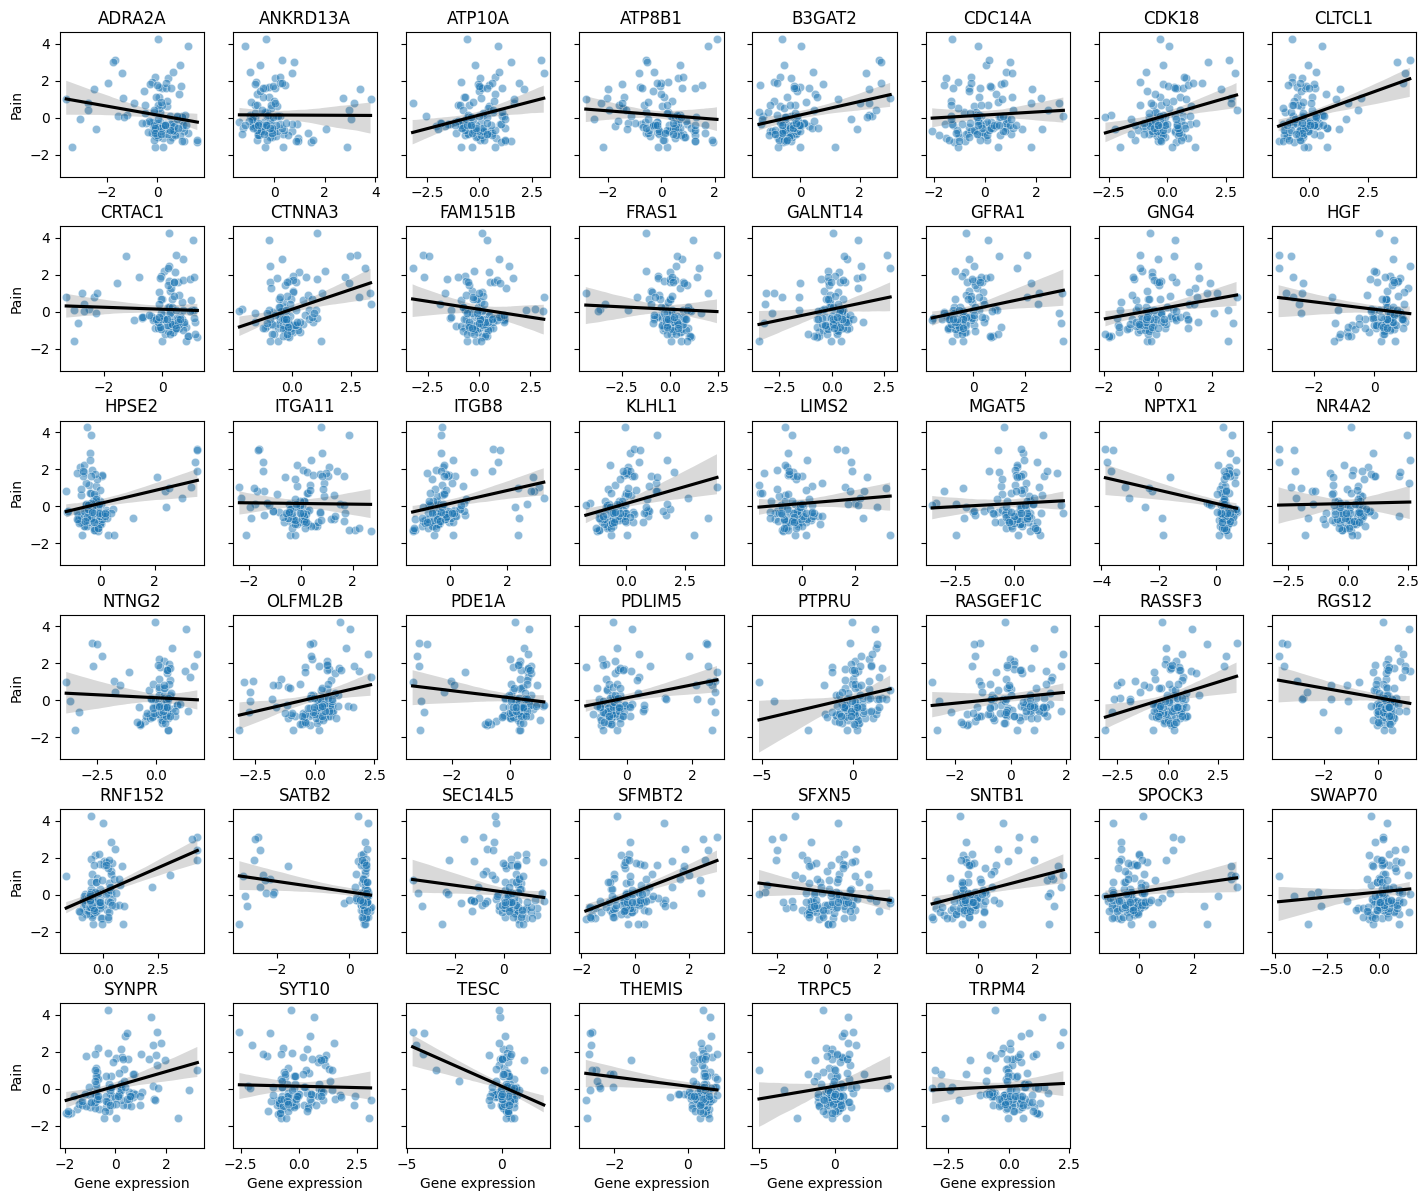

In [17]:
import numpy as np
import seaborn as sn

# we will extract the data from the "random input" nispace object fitted above

# extract parcellated input map vector
y = nispace_object_randominput.get_y().loc["Pain"]
print("Parcellated input map vector shape:", y.shape)
display(y.head())

# extract parcellated gene expression vectors
# the x dataset will have a multi-index with set names as first level and gene names as second level
x = nispace_object_randominput.get_x()
print("Parcellated gene expression vectors shape:", x.shape)
display(x.head())

# the set we want to inspect 
set_name = "Ex8 Corticothalamic (L6)"
set_genes = x.loc[set_name].index.to_list()
set_n = len(set_genes)
print(f"Set {set_name} has {set_n} genes.")

# create a figure with subplots for all the scatterplots
ncol = 8
nrow = np.ceil(set_n / ncol).astype(int)
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 1.8, nrow * 2), sharey=True)
axes = axes.ravel()

# plot each scatterplot
for gene_i, gene_name in enumerate(set_genes):
    
    # get ax and force square aspect ratio
    ax = axes[gene_i]
    ax.set_box_aspect(1)
    
    # plot scatterplot
    sn.scatterplot(y=y, x=x.loc[(set_name, gene_name)], ax=ax, alpha=0.5)
    sn.regplot(y=y, x=x.loc[(set_name, gene_name)], ax=ax, scatter=False, color="k")
    
    # set title
    ax.set_title(gene_name)
    ax.set_xlabel("Gene expression" if ax.get_subplotspec().is_last_row() else "")

# turn off empty axes
[ax.set_visible(False) for ax in axes if not ax.has_data()]
        
fig.tight_layout()